# ⚙️ Notebook 03 — Feature Engineering
**Goal:** Scale features, handle class imbalance (SMOTE), select top features.

---

In [1]:
# !pip install imbalanced-learn shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE
import pickle, os, warnings
warnings.filterwarnings('ignore')
print('✅ Libraries loaded')

✅ Libraries loaded


## 1️⃣ Load Data

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val   = pd.read_csv('../data/processed/X_val.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/processed/y_val.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()
print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (4930, 22) | Val: (1056, 22) | Test: (1057, 22)


## 2️⃣ StandardScaler

In [3]:
NUM_COLS = ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen']
scaler = StandardScaler()
X_train[NUM_COLS] = scaler.fit_transform(X_train[NUM_COLS])
X_val[NUM_COLS]   = scaler.transform(X_val[NUM_COLS])
X_test[NUM_COLS]  = scaler.transform(X_test[NUM_COLS])
os.makedirs('../models', exist_ok=True)
with open('../models/scaler.pkl','wb') as f: pickle.dump(scaler, f)
print('✅ Scaled and saved scaler.pkl')

✅ Scaled and saved scaler.pkl


## 3️⃣ SMOTE — Balance Classes

Before SMOTE: {0: 3557, 1: 1373}
After SMOTE:  {1: 3557, 0: 3557}


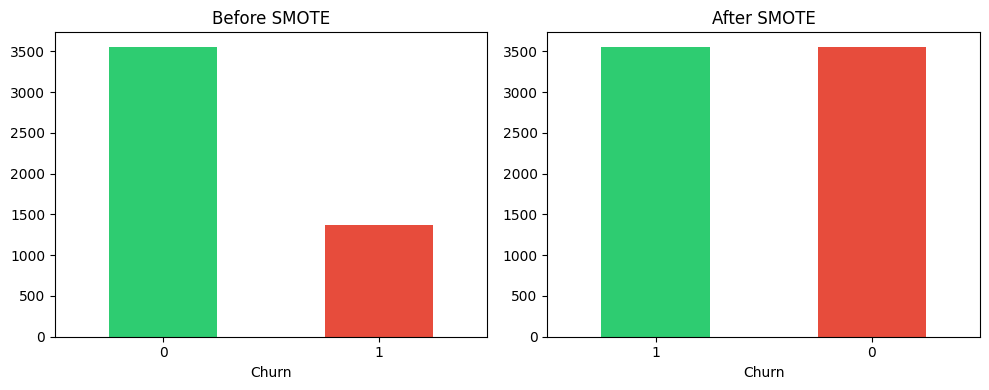

In [4]:
print('Before SMOTE:', y_train.value_counts().to_dict())
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train, y_train)
print('After SMOTE: ', pd.Series(y_sm).value_counts().to_dict())

fig, axes = plt.subplots(1,2,figsize=(10,4))
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], title='Before SMOTE', rot=0)
pd.Series(y_sm).value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'], title='After SMOTE', rot=0)
plt.tight_layout()
plt.savefig('../data/processed/03_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4️⃣ Feature Importance — Mutual Information

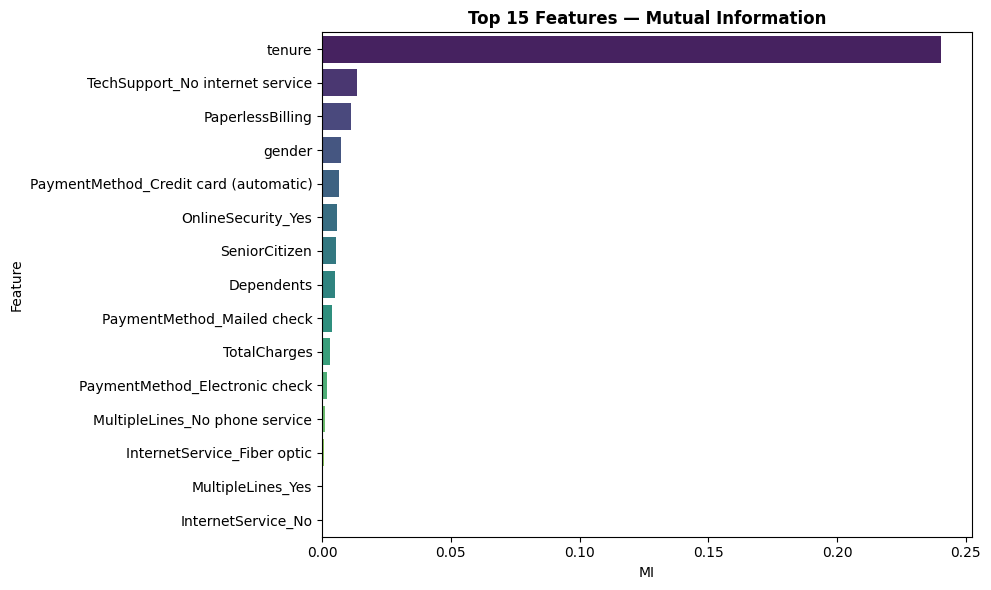

                              Feature       MI
                               tenure 0.240264
      TechSupport_No internet service 0.013404
                     PaperlessBilling 0.011227
                               gender 0.007532
PaymentMethod_Credit card (automatic) 0.006421
                   OnlineSecurity_Yes 0.005763
                        SeniorCitizen 0.005590
                           Dependents 0.005033
           PaymentMethod_Mailed check 0.003939
                         TotalCharges 0.002966
       PaymentMethod_Electronic check 0.001996
       MultipleLines_No phone service 0.001040
          InternetService_Fiber optic 0.000946
                    MultipleLines_Yes 0.000000
                   InternetService_No 0.000000


In [5]:
mi = mutual_info_classif(X_sm, y_sm, random_state=42)
mi_df = pd.DataFrame({'Feature': X_train.columns, 'MI': mi}).sort_values('MI', ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(data=mi_df, x='MI', y='Feature', palette='viridis')
plt.title('Top 15 Features — Mutual Information', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(mi_df.to_string(index=False))

## 5️⃣ Save Engineered Data

In [6]:
pd.DataFrame(X_sm, columns=X_train.columns).to_csv('../data/processed/X_train_smote.csv', index=False)
pd.Series(y_sm, name='Churn').to_csv('../data/processed/y_train_smote.csv', index=False)
X_val.to_csv('../data/processed/X_val_scaled.csv', index=False)
X_test.to_csv('../data/processed/X_test_scaled.csv', index=False)
print('✅ All saved!')
print(os.listdir('../data/processed/'))

✅ All saved!
['01_categorical_churn.png', '01_churn_distribution.png', '01_numerical_features.png', '03_feature_importance.png', '03_smote_balance.png', 'churn_processed.csv', 'X_test.csv', 'X_test_scaled.csv', 'X_train.csv', 'X_train_smote.csv', 'X_val.csv', 'X_val_scaled.csv', 'y_test.csv', 'y_train.csv', 'y_train_smote.csv', 'y_val.csv']


## ✅ Summary

- StandardScaler applied to numerical cols
- SMOTE balanced training set
- Top features: tenure, MonthlyCharges, TotalCharges

➡️ Next: `04_Model_Training_MLflow.ipynb`